# NBA Player Archetypes — K-Means Clustering (Revised)

**Goal:** Group NBA players into meaningful archetypes based on how they actually play — not what position label they wear.

**Why K-Means?**  
K-Means is an *unsupervised* learning algorithm. That means we don't tell it the answer ahead of time  we just hand it stats and let it find natural groupings on its own. It works by:
1. Picking k random "center points" (centroids)
2. Assigning every player to the nearest centroid
3. Moving each centroid to the average of its assigned players
4. Repeating steps 2-3 until nothing changes


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nba_api.stats.endpoints import leaguedashplayerstats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Pull 2024-25 season stats from the NBA API
stats = leaguedashplayerstats.LeagueDashPlayerStats(season='2024-25')
df = stats.get_data_frames()[0]

print(f"Total players in dataset: {len(df)}")
print(f"Columns available: {list(df.columns)}")


Total players in dataset: 569
Columns available: ['PLAYER_ID', 'PLAYER_NAME', 'NICKNAME', 'TEAM_ID', 'TEAM_ABBREVIATION', 'AGE', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS', 'NBA_FANTASY_PTS', 'DD2', 'TD3', 'WNBA_FANTASY_PTS', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'FGM_RANK', 'FGA_RANK', 'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK', 'FG3_PCT_RANK', 'FTM_RANK', 'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK', 'DREB_RANK', 'REB_RANK', 'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK', 'BLKA_RANK', 'PF_RANK', 'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK', 'NBA_FANTASY_PTS_RANK', 'DD2_RANK', 'TD3_RANK', 'WNBA_FANTASY_PTS_RANK', 'TEAM_COUNT']


# Filter and Select Features

**Why filter by minutes?**  
Players with very few minutes have noisy averages. A player who scored 10 points in 5 minutes looks like a superstar statistically, but that's not a real pattern. We keep players averaging 20+ minutes to focus on genuine rotation players.

**Why these features (and not the old ones)?**  
The original 8 features caused guards and centers to land in the same cluster because they share similar PTS and AST profiles. We fix this by adding features that better separate *how* players play:


In [2]:
# These were chosen to better separate guards, wings, and bigs
features = ['PTS', 'AST', 'OREB', 'DREB', 'STL', 'BLK', 'FG3A', 'FG_PCT','FGA', 'FTA']


# Filter: only keep players averaging 20+ minutes per game
# This removes garbage-time players whose small sample sizes produce misleading averages
df_clean = df[df['MIN'] >= 20].copy()
df_clean = df_clean.dropna(subset=features)  # drop any rows missing a feature value

print(f"Players after filtering (20+ MPG): {len(df_clean)}")
print("\nSample of data:")
df_clean[['PLAYER_NAME'] + features].head(10)

Players after filtering (20+ MPG): 548

Sample of data:


,PLAYER_NAME,PTS,AST,OREB,DREB,STL,BLK,FG3A,FG_PCT,FGA,FTA
0,A.J. Lawson,236,31,20,66,13,6,101,0.421,190,63
1,AJ Green,541,108,18,156,37,7,363,0.429,424,27
2,AJ Johnson,220,76,8,51,12,3,90,0.385,213,37
3,Aaron Gordon,748,164,80,167,23,14,172,0.531,497,179
4,Aaron Holiday,340,83,13,65,19,11,181,0.437,268,41
5,Aaron Nesmith,541,54,37,141,35,17,195,0.507,379,80
6,Aaron Wiggins,914,134,81,214,60,18,339,0.488,728,89
7,Adam Flagler,65,12,7,20,8,3,72,0.260,96,2
8,Adama Sanogo,8,1,5,1,0,0,0,0.571,7,0
9,Adem Bona,337,27,92,153,26,69,1,0.703,192,100


## Standardize the Features
**Why standardize?**  
K-Means measures distance between players. If PTS goes from 5–35 and FG_PCT goes from 0.40–0.65, the points column will completely dominate the distance calculation just because its numbers are bigger — even if FG_PCT is equally important.


In [3]:
scaler = StandardScaler()
X = scaler.fit_transform(df_clean[features])

# Quick sanity check — each column should now be centered around 0
print("Mean of each feature after scaling (should be ~0):")
print(X.mean(axis=0).round(4))

print("\nStd dev of each feature after scaling (should be ~1):")
print(X.std(axis=0).round(4))

Mean of each feature after scaling (should be ~0):
[ 0.  0. -0. -0. -0. -0. -0.  0. -0. -0.]

Std dev of each feature after scaling (should be ~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Choose the Right Number of Clusters (k)
We use two diagnostic tools:

**1. Elbow Method (Inertia)**  
Inertia measures the total distance between each player and their cluster center. Lower is better, but it always goes down as k increases. We look for the "elbow" the point where adding more clusters stops buying us much.

**2. Silhouette Score**  
Scores each player on how well they fit their assigned cluster vs. how close they are to the next best cluster. Ranges from -1 (bad) to 1 (perfect). Higher is better.  
We use this as a sanity check alongside the elbow — we don't just pick the k with the highest silhouette if it produces only 2 clusters (too coarse to be useful).

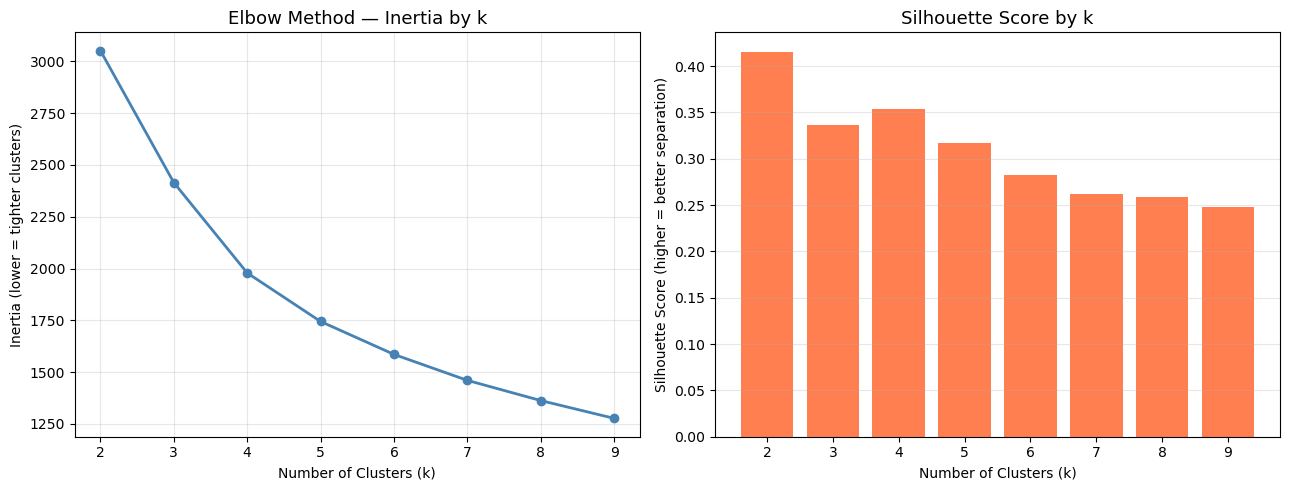

k | Silhouette Score
2 | 0.4158
3 | 0.3366
4 | 0.3540
5 | 0.3174
6 | 0.2827
7 | 0.2616
8 | 0.2587
9 | 0.2476


In [4]:
inertias = []
silhouettes = []
K_range = range(2, 10)  # test k from 2 to 9

for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    # n_init=20 means we try 20 different random starting points
    # and keep the best result — this avoids getting stuck in a bad local minimum
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

# Plot both diagnostics side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(list(K_range), inertias, marker='o', color='steelblue', linewidth=2)
ax1.set_title('Elbow Method — Inertia by k', fontsize=13)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (lower = tighter clusters)')
ax1.grid(alpha=0.3)

ax2.bar(list(K_range), silhouettes, color='coral')
ax2.set_title('Silhouette Score by k', fontsize=13)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score (higher = better separation)')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

# Print scores for easy reference
print("k | Silhouette Score")
for k, s in zip(K_range, silhouettes):
    print(f"{k} | {s:.4f}")

In [5]:
k = 7

km_final = KMeans(n_clusters=k, n_init=20, random_state=42)
df_clean['cluster'] = km_final.fit_predict(X)

# Show how many players ended up in each cluster
print("Players per cluster:")
print(df_clean['cluster'].value_counts().sort_index())

Players per cluster:
cluster
0    113
1     23
2    152
3     89
4     46
5     46
6     79
Name: count, dtype: int64


## Cluster Inspection

In [6]:
# Printing the average stats for each cluster
print("=== Cluster Centroids (Average Stats) ===")
centroids = df_clean.groupby('cluster')[features].mean().round(2)
print(centroids)

print("\n" + "="*50)

# Printing the player names in each cluster so we can interpret them
for c in sorted(df_clean['cluster'].unique()):
    players = df_clean[df_clean['cluster'] == c]['PLAYER_NAME'].values
    print(f"\n--- Cluster {c} ({len(players)} players) ---")
    print(', '.join(players))

=== Cluster Centroids (Average Stats) ===
             PTS     AST    OREB    DREB    STL    BLK    FG3A  FG_PCT  \
cluster                                                                  
0         481.36  107.15   43.48  136.70  38.50  17.36  206.01    0.44   
1        1172.70  222.96  189.48  489.78  64.96  91.35  173.70    0.56   
2         102.10   28.63   11.95   32.72  11.20   4.30   48.22    0.38   
3         884.46  208.37   62.90  219.00  71.04  27.87  344.38    0.45   
4         521.89   92.48  125.41  249.98  39.50  53.37   74.83    0.55   
5        1519.67  406.65   61.20  303.54  77.26  30.96  470.43    0.46   
6         132.27   27.72   26.16   56.90  11.82  11.63   26.41    0.56   

             FGA     FTA  
cluster                   
0         394.88   74.93  
1         838.61  274.70  
2          92.78   17.03  
3         709.76  143.78  
4         384.26  115.78  
5        1150.80  341.07  
6          96.99   26.70  


--- Cluster 0 (113 players) ---
AJ Green, Aaro

## Label the Clusters

In [7]:
cluster_labels = {
    0: 'Primary Offensive Engines',
    1: '3-and-D Wings',
    2: 'Secondary Playmakers',
    3: 'Rim-Running Bigs',
    4: 'Stretch / Skilled Bigs',
    5: 'Defensive Role Players',
    6: 'Low-Usage Role Players'
}

df_clean['archetype'] = df_clean['cluster'].map(cluster_labels)

print("Archetype distribution:")
print(df_clean['archetype'].value_counts())

Archetype distribution:
archetype
Secondary Playmakers         152
Primary Offensive Engines    113
Rim-Running Bigs              89
Low-Usage Role Players        79
Stretch / Skilled Bigs        46
Defensive Role Players        46
3-and-D Wings                 23
Name: count, dtype: int64


## Visualize with PCA

PC1 explains 63.1% of variance
PC2 explains 17.9% of variance
Total explained: 81.0%


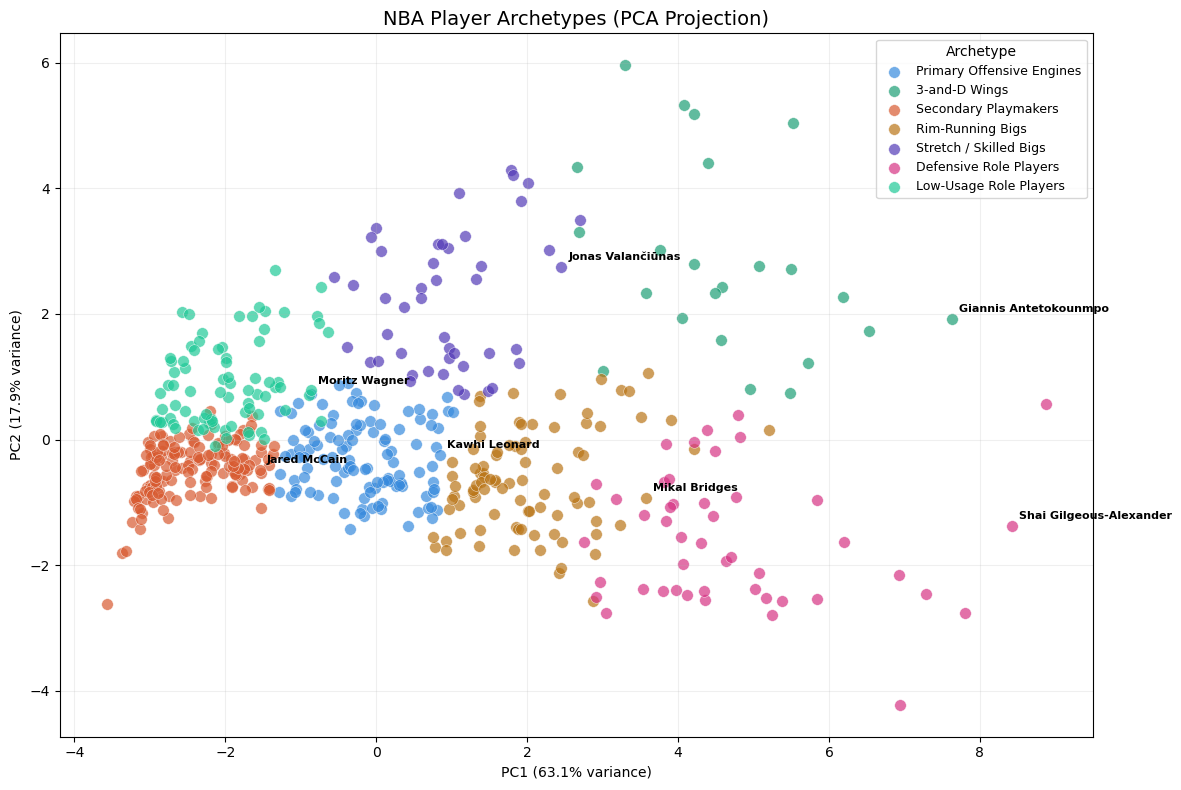

In [8]:
# Compress 9 features down to 2 dimensions for plotting
pca = PCA(n_components=2)
coords = pca.fit_transform(X)
df_clean['pc1'] = coords[:, 0]
df_clean['pc2'] = coords[:, 1]

# How much variance do the two components explain?
print(f"PC1 explains {pca.explained_variance_ratio_[0]:.1%} of variance")
print(f"PC2 explains {pca.explained_variance_ratio_[1]:.1%} of variance")
print(f"Total explained: {sum(pca.explained_variance_ratio_[:2]):.1%}")

# Color palette — one color per cluster
colors = ['#378add', '#1d9e75', '#d85a30', '#ba7517', '#533ab7', '#d63384', '#20c997']

fig, ax = plt.subplots(figsize=(12, 8))

for c in sorted(df_clean['cluster'].unique()):
    mask = df_clean['cluster'] == c
    label = cluster_labels[c]
    ax.scatter(
        df_clean.loc[mask, 'pc1'],
        df_clean.loc[mask, 'pc2'],
        label=label,
        color=colors[c],
        alpha=0.7,
        s=70,
        edgecolors='white',
        linewidths=0.4
    )
    
    # highlight the top scorer in each cluster as an example
    top_player = df_clean[mask].nlargest(1, 'PTS')
    for _, row in top_player.iterrows():
        ax.annotate(
            row['PLAYER_NAME'],
            (row['pc1'], row['pc2']),
            fontsize=8,
            fontweight='bold',
            xytext=(5, 5),
            textcoords='offset points'
        )

ax.legend(loc='upper right', fontsize=9, title='Archetype')
ax.set_title('NBA Player Archetypes (PCA Projection)', fontsize=14)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Radar Chart
The radar chart shows the *shape* of each archetype, what makes each cluster unique across all 9 features at once.

Each axis is one feature. A cluster that peaks on REB and BLK but is low on AST and FG3A is clearly a traditional big. A cluster that peaks on AST and PTS but is low on REB and BLK is clearly a guard/creator.

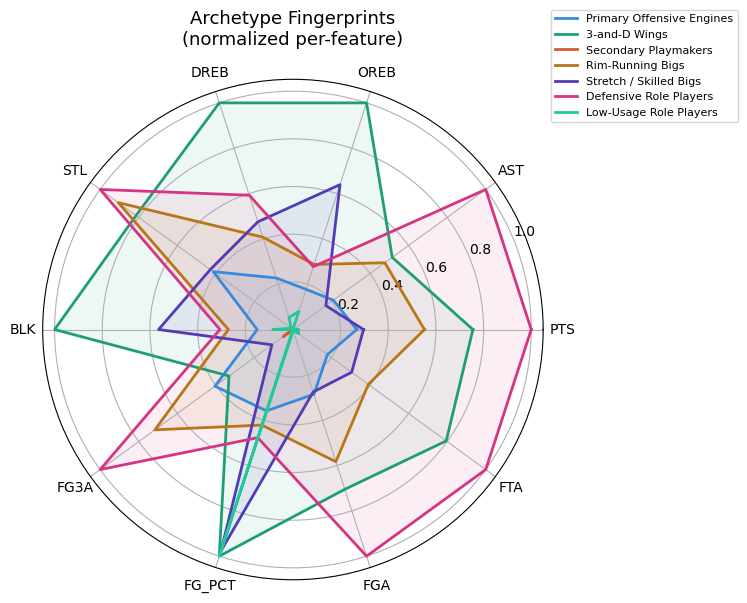

In [9]:
# Compute average stats per cluster, then normalize to 0-1 scale for the radar
# Normalizing is important so that high-magnitude features (PTS) don't visually dominate
centroid_vals = df_clean.groupby('cluster')[features].mean()
centroid_norm = (centroid_vals - centroid_vals.min()) / (centroid_vals.max() - centroid_vals.min())


angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]  # close the circle

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for c in sorted(df_clean['cluster'].unique()):
    vals = centroid_norm.loc[c].tolist()
    vals += vals[:1]  # close the polygon
    ax.plot(angles, vals, color=colors[c], linewidth=2, label=cluster_labels[c])
    ax.fill(angles, vals, color=colors[c], alpha=0.08)

ax.set_thetagrids(np.degrees(angles[:-1]), features, fontsize=10)
ax.set_title('Archetype Fingerprints\n(normalized per-feature)', pad=25, fontsize=13)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=8)
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## Supervised Learning

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

In [11]:
# X = the same 10 features we used for clustering
# y = the archetype labels K-Means + manual inspection produced
X_sup = df_clean[features].values
y_sup = df_clean['archetype'].values

# Split: 80% train, 20% test
# random_state=42 makes the split reproducible 
# stratify=y_sup ensures each archetype is proportionally represented in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X_sup, y_sup,
    test_size=0.2,
    random_state=42,
    stratify=y_sup
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")

Training samples: 438
Test samples:     110


## Train the Random Forest

In [12]:
rf = RandomForestClassifier(
    n_estimators=200,   # 200 decision trees
    max_depth=10,    
    random_state=42
)
rf.fit(X_train, y_train)

print("Model trained successfully.")
print(f"Number of trees: {rf.n_estimators}")

Model trained successfully.
Number of trees: 200


In [13]:
# Generate predictions on the test set
y_pred = rf.predict(X_test)

# Overall accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {acc:.1%}\n")

# Per-archetype breakdown
print("Classification Report:")
print(classification_report(y_test, y_pred))

Overall Accuracy: 90.0%

Classification Report:
                           precision    recall  f1-score   support

            3-and-D Wings       1.00      0.80      0.89         5
   Defensive Role Players       0.86      0.67      0.75         9
   Low-Usage Role Players       0.89      1.00      0.94        16
Primary Offensive Engines       0.95      0.91      0.93        23
         Rim-Running Bigs       0.78      1.00      0.88        18
     Secondary Playmakers       0.96      0.90      0.93        30
   Stretch / Skilled Bigs       0.88      0.78      0.82         9

                 accuracy                           0.90       110
                macro avg       0.90      0.87      0.88       110
             weighted avg       0.91      0.90      0.90       110



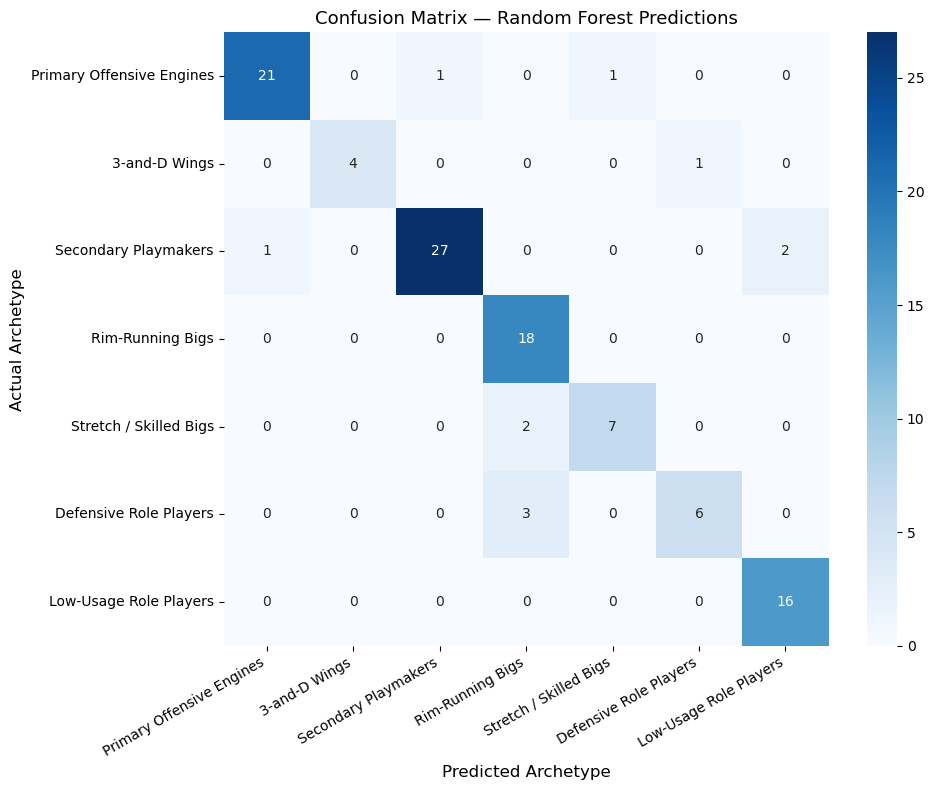

In [14]:
# Confusion Matrix — visualize where the model gets confused
archetype_names = list(cluster_labels.values())

cm = confusion_matrix(y_test, y_pred, labels=archetype_names)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=archetype_names,
    yticklabels=archetype_names,
    ax=ax
)
ax.set_xlabel('Predicted Archetype', fontsize=12)
ax.set_ylabel('Actual Archetype', fontsize=12)
ax.set_title('Confusion Matrix — Random Forest Predictions', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


**How to read this:
 Diagonal = correct predictions (darker = better)
 Off-diagonal = mistakes — which archetypes are being confused with each other**

## Feature Importance

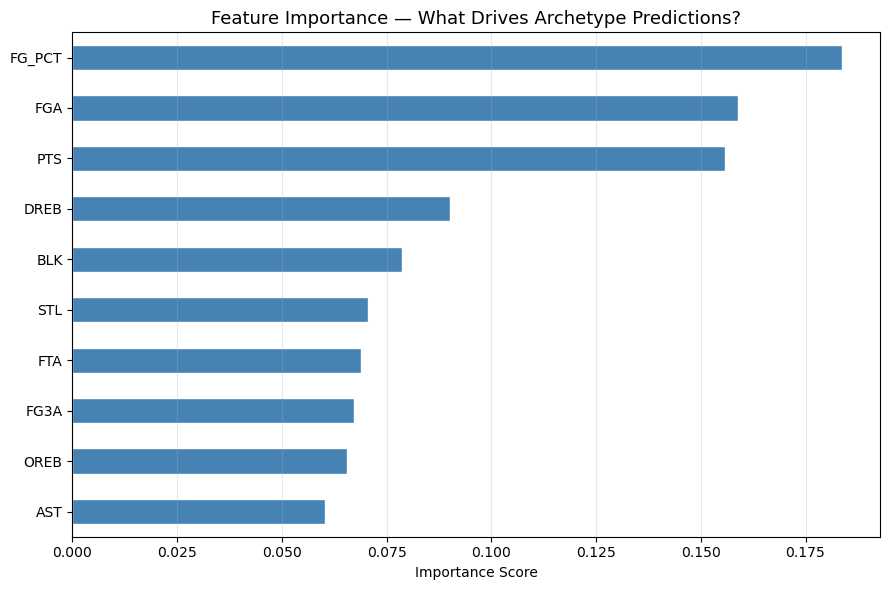

Feature Importances (ranked):
FG_PCT    0.1836
FGA       0.1589
PTS       0.1557
DREB      0.0902
BLK       0.0788
STL       0.0706
FTA       0.0690
FG3A      0.0672
OREB      0.0656
AST       0.0604
dtype: float64


In [15]:
# Extract feature importances and sort them
importances = pd.Series(rf.feature_importances_, index=features)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importance — What Drives Archetype Predictions?', fontsize=13)
ax.set_xlabel('Importance Score')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature Importances (ranked):")
print(importances.sort_values(ascending=False).round(4))

## Predict a New Player's Archetype

In [18]:
def predict_archetype(player_name, stats_dict):
    player_df = pd.DataFrame([stats_dict], columns=features)
    player_scaled = scaler.transform(player_df)
    prediction = rf.predict(player_scaled)[0]
    probabilities = rf.predict_proba(player_scaled)[0]
    confidence = max(probabilities)
    print(f"{player_name}: {prediction} (confidence: {confidence:.1%})")

# --- Test on some well-known players from the dataset ---

# Example: a player profile resembling a star ball-handler
predict_archetype("Star Ball-Handler Profile", {
    'PTS': 27.5, 'AST': 7.2, 'OREB': 0.5, 'DREB': 4.1,
    'STL': 1.3, 'BLK': 0.4, 'FG3A': 7.8, 'FG_PCT': 0.48,
    'FGA': 19.2, 'FTA': 6.5
})

# Example: a player profile resembling a 3-and-D wing
predict_archetype("3-and-D Wing Profile", {
    'PTS': 11.2, 'AST': 1.8, 'OREB': 0.6, 'DREB': 3.5,
    'STL': 1.1, 'BLK': 0.5, 'FG3A': 5.2, 'FG_PCT': 0.47,
    'FGA': 8.1, 'FTA': 1.8
})

# Example: a player profile resembling a rim-running big
predict_archetype("Rim-Running Big Profile", {
    'PTS': 13.5, 'AST': 1.2, 'OREB': 3.1, 'DREB': 7.8,
    'STL': 0.7, 'BLK': 1.8, 'FG3A': 0.3, 'FG_PCT': 0.62,
    'FGA': 8.9, 'FTA': 4.2
})

Star Ball-Handler Profile: Secondary Playmakers (confidence: 86.5%)
3-and-D Wing Profile: Secondary Playmakers (confidence: 86.5%)
Rim-Running Big Profile: Low-Usage Role Players (confidence: 91.5%)
